# Exercise 6 - Euler Backward

Vivienne Banks

BNKVIV001

1 June 2026

### Euler Backward
AI Prompt:
Please modify this code (insert of python code for the forward Euler equation) to plot the Euler-backward equation instead.

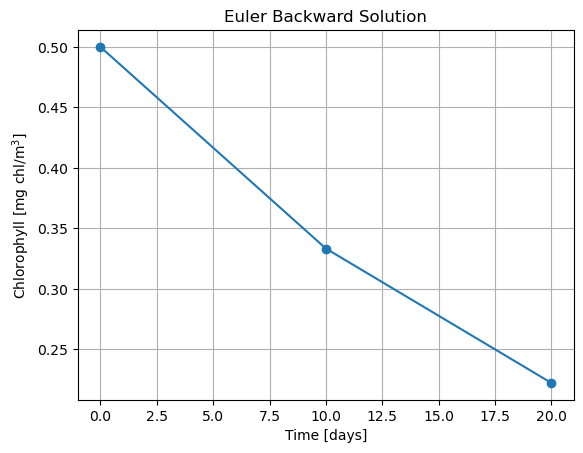

In [1]:
"""
Numerical solution of the decay equation
using the Euler-Backward method
"""

import numpy as np
import matplotlib.pyplot as plt

# Parameters
t0 = 0.0
tn = 20.0
dt = 10.0

kappa = 0.05      # day^-1
C0 = 0.5          # mg chl m^-3

# Number of timesteps
Ntot = int(np.floor((tn - t0) / dt) + 1)

# Arrays
C = np.zeros(Ntot)
t = np.zeros(Ntot)

# Initial conditions
C[0] = C0
t[0] = t0

# Euler-backward loop
for n in range(Ntot - 1):

    C[n+1] = C[n] / (1 + kappa*dt)

    t[n+1] = t[n] + dt

# Plot
plt.plot(t, C, 'o-')
plt.xlabel('Time [days]')
plt.ylabel('Chlorophyll [mg chl/m$^3$]')
plt.title('Euler Backward Solution')
plt.grid()
plt.show()

### Euler Forward
AI formatted the code provided in the notes for easy copying and pasting into the Notebook.

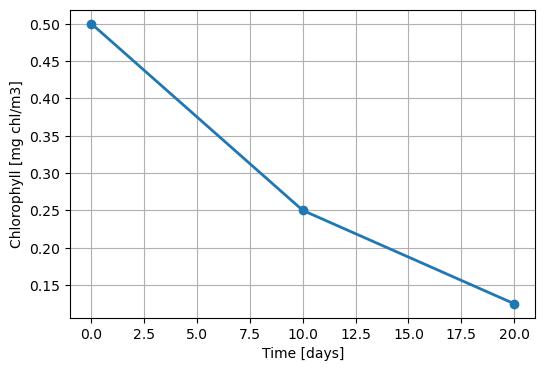

In [4]:
"""
A numerical solution of the decay equation
using the Euler-Forward method.
"""

import pylab as pl

# Parameters
t0 = 0.0           # time is in days
tn = 20.0
dt = 10.0

kappa = 0.05       # day^-1
C0 = 0.5           # mg chl/m^3

# Define the RHS of the equation
def F(k, C):
    return -k * C

# Compute the total number of steps
Ntot = (pl.floor((tn - t0) / dt) + 1).astype(int)

# Initialization
C = pl.zeros(Ntot)
t = C.copy()

t[0] = t0
C[0] = C0

# Forward Euler loop
for n in range(Ntot - 1):

    C[n+1] = C[n] + F(kappa, C[n]) * dt

    t[n+1] = t[n] + dt

# Plot
pl.figure(figsize=(6,4))
pl.plot(t, C, linewidth=2, marker = "o")

pl.xlabel('Time [days]')
pl.ylabel('Chlorophyll [mg chl/m3]')
pl.grid()

pl.show()

# Comparison between Euler Backward & Forward

AI Prompt: Can you please write the code to plot the time step comparisons [for the forward and backward equations]

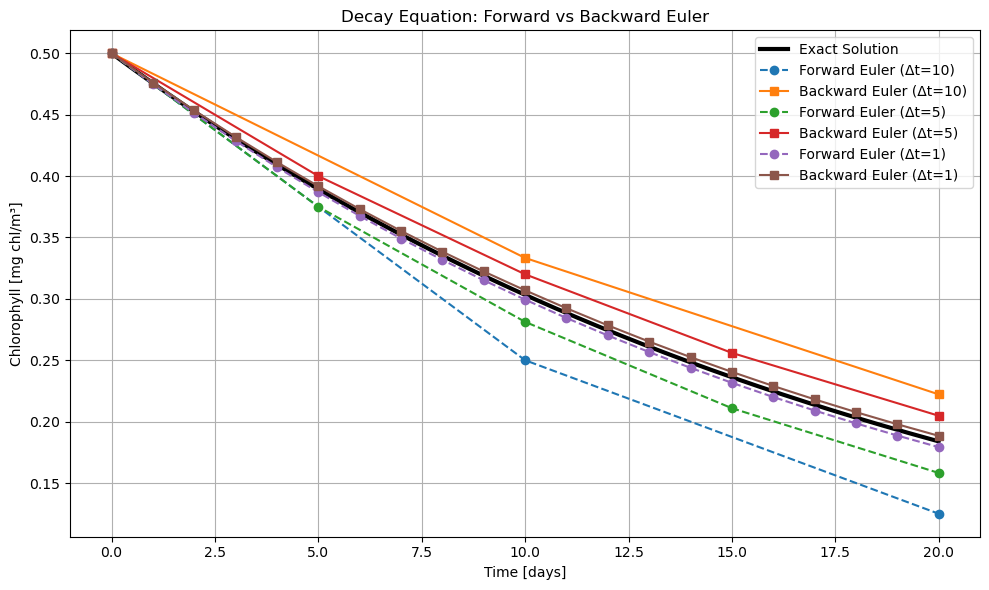

In [5]:
"""
Comparison of Forward Euler, Backward Euler,
and Exact Solution for the decay equation

dC/dt = -kC
"""

import numpy as np
import matplotlib.pyplot as plt

# Parameters
t0 = 0.0
tn = 20.0
kappa = 0.05
C0 = 0.5

# Timesteps to compare
dt_values = [10, 5, 1]

# Exact solution
t_exact = np.linspace(t0, tn, 500)
C_exact = C0 * np.exp(-kappa * t_exact)

# Create figure
plt.figure(figsize=(10, 6))

# Plot exact solution
plt.plot(
    t_exact,
    C_exact,
    'k-',
    linewidth=3,
    label='Exact Solution'
)

# Loop through timestep values
for dt in dt_values:

    Ntot = int(np.floor((tn - t0)/dt) + 1)

    t = np.zeros(Ntot)
    C_forward = np.zeros(Ntot)
    C_backward = np.zeros(Ntot)

    # Initial conditions
    t[0] = t0
    C_forward[0] = C0
    C_backward[0] = C0

    # Time stepping
    for n in range(Ntot - 1):

        # Forward Euler
        C_forward[n+1] = (
            C_forward[n]
            - kappa * C_forward[n] * dt
        )

        # Backward Euler
        C_backward[n+1] = (
            C_backward[n]
            / (1 + kappa * dt)
        )

        t[n+1] = t[n] + dt

    # Plot Forward Euler
    plt.plot(
        t,
        C_forward,
        'o--',
        label=f'Forward Euler (Δt={dt})'
    )

    # Plot Backward Euler
    plt.plot(
        t,
        C_backward,
        's-',
        label=f'Backward Euler (Δt={dt})'
    )

# Formatting
plt.xlabel('Time [days]')
plt.ylabel('Chlorophyll [mg chl/m³]')
plt.title('Decay Equation: Forward vs Backward Euler')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

This plot shows that the Forward Euler Equation approaches the solution from the below the curve while the Backward Euler equation approaches the sloution from above the curve.

In both cases, a shorter time-step gives a more accurate curve.